# **Import Trade Analysis Using Python (2015–2025)**

#**1.1 Dataset information**

Source : India Data Portal


Location : India Asia

Year/Timeline : 2015 to 2025

Domain: Import Trade

# **1.2 Problem Statement**

International import trade data contains information about many countries, commodities, regions, and time periods. However, it is difficult to identify the major importing countries, high-value commodities, and overall import trends directly from the raw data. This project aims to analyze these trade patterns and identify the key factors contributing to import activity

# **1.3 Objective**

1. Identify the major importing countries based on import value and trade activity.


2. Identify the major commodities contributing to import activity.

3. Analyze import trends over time to understand changes in trade activity.

4. Compare import activity across major countries and trade subregions.

5. Analyze the distribution and variation of import values using appropriate statistical measures and visualizations.

6. Identify significant patterns and provide data-driven insights into international import trade.




In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Assignments/Major Project/Dataset/imports-from-asian-countries.csv')

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [ ]:
df

,id,date,country_name,alpha_3_code,country_code,region_name,region_code,subregion_name,subregion_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
0,0,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7133100,"*Beans Of The Spp Vigna Mungo,Hepper Or Vigna ...",Kgs,73.00,56.30,0.09
1,1,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7133990,Other Dried Leguminus Vegetables,Kgs,48.00,33.73,0.05
2,2,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7136000,Pigeon Peas (Cajanus Cajan),Kgs,96.00,49.14,0.08
3,3,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,8021100,Almonds Frsh Or Driedin Shell,Kgs,45.80,110.61,0.18
4,4,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,8021200,Shelled Almonds Frsh Or Dried,Kgs,190.61,796.56,1.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3188525,3188525,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,74040012,"Copper Scrap Covered By Isri Code Barley, Berr...",Kgs,41220.00,3.63,0.41
3188526,3188526,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,76020010,Aluminium Scrap Coverd By Isri Code Tablettabl...,Kgs,352985.00,7.52,0.85
3188527,3188527,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,78019920,"Unrefined Lead,N.E.S.",Kgs,44620.00,0.80,0.09
3188528,3188528,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,79020010,"Zinc Scrap Covered By Isri Code Saves, Scab,Sc...",Kgs,22395.00,0.43,0.05


In [ ]:
df.head()

,id,date,country_name,alpha_3_code,country_code,region_name,region_code,subregion_name,subregion_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
0,0,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7133100,"*Beans Of The Spp Vigna Mungo,Hepper Or Vigna ...",Kgs,73.00,56.30,0.09
1,1,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7133990,Other Dried Leguminus Vegetables,Kgs,48.00,33.73,0.05
2,2,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,7136000,Pigeon Peas (Cajanus Cajan),Kgs,96.00,49.14,0.08
3,3,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,8021100,Almonds Frsh Or Driedin Shell,Kgs,45.80,110.61,0.18
4,4,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,8021200,Shelled Almonds Frsh Or Dried,Kgs,190.61,796.56,1.28


#**2. Exploratory Data Analysis (EDA)**

**2.1 Dataset Overview**

In [ ]:
# Number of rows and columns (Shape)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3188530
Columns: 15


In [ ]:
# Information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188530 entries, 0 to 3188529
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   country_name    object 
 3   alpha_3_code    object 
 4   country_code    int64  
 5   region_name     object 
 6   region_code     int64  
 7   subregion_name  object 
 8   subregion_code  int64  
 9   hs_code         int64  
 10  commodity       object 
 11  unit            object 
 12  value_qt        float64
 13  value_rs        float64
 14  value_dl        float64
dtypes: float64(3), int64(5), object(7)
memory usage: 364.9+ MB


In [ ]:
# Data types

df.dtypes

,0
id,int64
date,object
country_name,object
alpha_3_code,object
country_code,int64
region_name,object
region_code,int64
subregion_name,object
subregion_code,int64
hs_code,int64


**2.2 Missing Values Analysis**

In [ ]:
df.isnull().sum()

,0
id,0
date,0
country_name,0
alpha_3_code,0
country_code,0
region_name,0
region_code,0
subregion_name,0
subregion_code,0
hs_code,0


**2.3 Duplicate Records Analysis**

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)

Duplicate records: 0


**2.4 Descriptive Statistics**

In [ ]:
df.describe()

,id,country_code,region_code,subregion_code,hs_code,value_qt,value_rs,value_dl
count,3.188530e+06,3.188530e+06,3188530.0,3.188530e+06,3.188530e+06,3.188530e+06,3.188530e+06,3.188530e+06
mean,1.594264e+06,4.204500e+02,142.0,4.829870e+01,6.323124e+07,4.957690e+05,6.990128e+02,1.097427e+00
std,9.204495e+05,2.361076e+02,0.0,3.986170e+01,2.374960e+07,4.048260e+07,1.442160e+04,2.092261e+01
min,0.000000e+00,4.000000e+00,142.0,3.000000e+01,1.012100e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.971322e+05,1.560000e+02,142.0,3.000000e+01,3.924109e+07,2.100000e-01,2.160000e+00,1.000000e-02
50%,1.594264e+06,3.920000e+02,142.0,3.000000e+01,7.113194e+07,5.080000e+00,1.842000e+01,4.000000e-02
75%,2.391397e+06,7.020000e+02,142.0,3.500000e+01,8.474801e+07,9.159000e+01,1.212800e+02,2.200000e-01
max,3.188529e+06,8.870000e+02,142.0,1.450000e+02,9.993002e+07,2.274650e+10,2.999505e+06,3.852410e+03


**2.5 Unique Values Analysis**

In [ ]:
df.nunique()

,0
id,3188530
date,130
country_name,51
alpha_3_code,50
country_code,50
region_name,1
region_code,1
subregion_name,5
subregion_code,5
hs_code,11852


# **3. Data Cleaning, Transformation and Feature Engineering**

**3.1 Data Cleaning**

In [ ]:
# Created a working copy

df = df.copy()

In [ ]:
# Records with missing unit values

df[df['unit'].isnull()]

,id,date,country_name,alpha_3_code,country_code,region_name,region_code,subregion_name,subregion_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
2829985,2829985,2024-10-01,China,CHN,156,Asia,142,Eastern Asia,30,99930010,Samples,NaN,0.0,0.02,0.00
2841299,2841299,2024-10-01,Republic of Korea,KOR,410,Asia,142,Eastern Asia,30,99930020,Returned Goods,NaN,0.0,0.44,0.05
2850897,2850897,2024-10-01,United Arab Emirates,ARE,784,Asia,142,Western Asia,145,99930020,Returned Goods,NaN,0.0,0.23,0.03
2858402,2858402,2024-11-01,China,CHN,156,Asia,142,Eastern Asia,30,99930010,Samples,NaN,0.0,0.02,0.00
2880216,2880216,2024-12-01,Bahrain,BHR,48,Asia,142,Western Asia,145,99930020,Returned Goods,NaN,0.0,0.22,0.03
2883119,2883119,2024-12-01,China,CHN,156,Asia,142,Eastern Asia,30,57033931,Nan,NaN,8331.0,0.27,0.03
2886514,2886514,2024-12-01,China,CHN,156,Asia,142,Eastern Asia,30,99930010,Samples,NaN,0.0,0.02,0.00
2893114,2893114,2024-12-01,Jordan,JOR,400,Asia,142,Western Asia,145,99930020,Returned Goods,NaN,0.0,1.15,0.14
2895349,2895349,2024-12-01,Oman,OMN,512,Asia,142,Western Asia,145,99930020,Returned Goods,NaN,0.0,1.82,0.21
2914683,2914683,2025-01-01,China,CHN,156,Asia,142,Eastern Asia,30,99930010,Samples,NaN,0.0,0.02,0.00


In [ ]:
# Remove records where unit is missing

df = df.dropna(subset=['unit'])

In [ ]:
# Missing values after cleaning

df.isnull().sum()

,0
id,0
date,0
country_name,0
alpha_3_code,0
country_code,0
region_name,0
region_code,0
subregion_name,0
subregion_code,0
hs_code,0


In [ ]:
print("Shape after handling missing values:", df.shape)

Shape after handling missing values: (3188475, 15)


**1. Zero-value investigation**

In [ ]:
# Checking Zeros

zero_values = pd.DataFrame({
    'Zero_Count': [
        (df['value_qt'] == 0).sum(),
        (df['value_rs'] == 0).sum(),
        (df['value_dl'] == 0).sum()
    ],
    'Zero_Percentage': [
        (df['value_qt'] == 0).mean() * 100,
        (df['value_rs'] == 0).mean() * 100,
        (df['value_dl'] == 0).mean() * 100
    ]
}, index=['value_qt', 'value_rs', 'value_dl'])

zero_values

,Zero_Count,Zero_Percentage
value_qt,191634,6.010209
value_rs,35455,1.111974
value_dl,760811,23.861282


**2. Unit checks**

In [ ]:
# Data-quality check on units

df['unit'].value_counts(dropna=False)

,count
unit,
Kgs,1977592
Nos,1012369
Sqm,97141
Mtr,28587
Prs,27080
Ltr,11126
Ton,8922
Cbm,8358
Ctm,7451


In [ ]:
# value " check

df[df['unit'] == '"']['commodity'].value_counts().head(20)

,count
commodity,
"""Calcium Hydrogenortho Phosphate (Dicalcium Phosphate",113
"""Klm, Schmcks, Krmne And Smlr Hndwvn",35
"""Camel-Black Strps Fr Retreading Rubr Tyr",13
"""Homogenised Or Reconstituted Toba",2
"""Indian Cotton Of Staple Length 28.5Mm (1.4/32) And Above But Below 34.5Mm",1
"""Indn Cotn Of Stpl Lngth Ovr 24.5Mm(31/32)To 28Mm Excluding Bengal Deshi",1


**3. Country checks**

In [ ]:
df['country_name'].nunique()

51

In [ ]:
# Country-code consistency

country_mapping = df[
    ['country_name', 'alpha_3_code', 'country_code']
].drop_duplicates()

country_mapping.shape

(51, 3)

In [ ]:
# standardizing Türkiye → Turkey

df['country_name'] = df['country_name'].replace('Türkiye', 'Turkey')

**4. Commodity checks**

In [ ]:
# Basic commodity check

print("Unique commodities:", df['commodity'].nunique())
print("Missing commodities:", df['commodity'].isna().sum())

Unique commodities: 10488
Missing commodities: 0


In [ ]:
# Suspicious commodity labels

suspicious_commodities = [
    'Others',
    'Other',
    '*Others',
    '0Thers',
    '*Other'
]

# Count

df[df['commodity'].isin(suspicious_commodities)]['commodity'].value_counts()

,count
commodity,
Others,227552
Other,104407
*Others,7269
0Thers,4846
*Other,2545


In [ ]:
# Checking HS codes associated with "Others" commodity category

zero_there_hs = df[
    df['commodity'].str.contains('Others', case=False, na=False)
]['hs_code'].unique()

print("Others HS codes:", len(zero_there_hs))

Others HS codes: 549


In [ ]:
# *Other / *Others HS-code investigation

star_commodities = df[
    df['commodity'].isin(['*Other', '*Others'])
][['hs_code', 'commodity']].drop_duplicates()

star_commodities.groupby('commodity')['hs_code'].nunique()

,hs_code
commodity,
*Other,17
*Others,19


In [ ]:
# Common HS codes between starred and non-starred labels

print("Common HS codes between *Other and Other:",
      len(
          set(df[df['commodity'] == '*Other']['hs_code'].unique()) &
          set(df[df['commodity'] == 'Other']['hs_code'].unique())
      ))

print("Common HS codes between *Others and Others:",
      len(
          set(df[df['commodity'] == '*Others']['hs_code'].unique()) &
          set(df[df['commodity'] == 'Others']['hs_code'].unique())
      ))

Common HS codes between *Other and Other: 2
Common HS codes between *Others and Others: 1


**3.2 Data Transformation**

In [ ]:
# Converting date column to datetime format

df['date'] = pd.to_datetime(df['date'])

In [ ]:
print(df['date'].dtype)

datetime64[ns]


**3.3 Feature Engineering & Transformation**

In [ ]:
# Creating year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [ ]:
# Month name
df['month_name'] = df['date'].dt.month_name()

# Creating quarter
df['quarter'] = df['date'].dt.quarter

# Creating quarter name
df['quarter_name'] = 'Q' + df['quarter'].astype(str)

# Creating year-month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

In [ ]:
# Verified

df[['date', 'year', 'month', 'month_name',
    'quarter', 'quarter_name', 'year_month']].head()

,date,year,month,month_name,quarter,quarter_name,year_month
0,2015-01-01,2015,1,January,1,Q1,2015-01
1,2015-01-01,2015,1,January,1,Q1,2015-01
2,2015-01-01,2015,1,January,1,Q1,2015-01
3,2015-01-01,2015,1,January,1,Q1,2015-01
4,2015-01-01,2015,1,January,1,Q1,2015-01


**3.4 Data Validation After Cleaning**

In [ ]:
# Final check

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3188475
Columns: 21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3188475 entries, 0 to 3188529
Data columns (total 21 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   country_name    object        
 3   alpha_3_code    object        
 4   country_code    int64         
 5   region_name     object        
 6   region_code     int64         
 7   subregion_name  object        
 8   subregion_code  int64         
 9   hs_code         int64         
 10  commodity       object        
 11  unit            object        
 12  value_qt        float64       
 13  value_rs        float64       
 14  value_dl        float64       
 15  year            int32         
 16  month           int32         
 17  month_name      object        
 18  quarter         int32         
 19  quarter_name    object        
 20  year_month      object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64(5), objec

## **4. Statistical Analysis**

**4.1 Mean, Median and Mode**



In [ ]:
import_value_stats = pd.Series({
    'Mean': df['value_rs'].mean(),
    'Median': df['value_rs'].median(),
    'Mode': df['value_rs'].mode().iloc[0]
})

import_value_stats

,0
Mean,699.024805
Median,18.420000
Mode,0.000000


**Interpretation**: The mean import value is ₹699.01, while the median is only ₹18.42, showing that a small number of high-value import records significantly increase the average. The mode is ₹0, indicating that zero-value records occur frequently in the dataset.

**4.2 Variance and Standard Deviation**

In [ ]:
variance = df['value_rs'].var()
standard_deviation = df['value_rs'].std()

print("Variance:", variance)
print("Standard Deviation:", standard_deviation)

Variance: 207986172.4442028
Standard Deviation: 14421.725709643864


**Interpretation**: The variance is approximately 207,986,172.44, and the standard deviation is approximately ₹14,421.73, indicating substantial variation in import values across trade records. The large standard deviation reflects the presence of highly different transaction values, including some very high-value observations.

**4.3 Skewness Analysis**

In [ ]:
# Skewness and Kurtosis of key import value

skewness = pd.Series({
    'Skewness': df['value_rs'].skew(),
    'Kurtosis': df['value_rs'].kurt()
})

skewness

,0
Skewness,90.409668
Kurtosis,11190.260543


**Interpretation**: The skewness of approximately 90.41 indicates a strong positive (right) skew in import values. This means that most trade records have relatively low values, while a smaller number of extremely high-value records create a long right tail in the distribution.

**4.4 Statistical Summary**

The statistical analysis of import value shows substantial variation and strong positive skewness. The mean is considerably higher than the median, indicating that a relatively small number of high-value trade records strongly influence the overall distribution. The high standard deviation and skewness further confirm the presence of extreme values. Therefore, median values, distribution analysis and trend-based comparisons are useful alongside mean-based measures when interpreting import trade data.

#**5. Data Visualization and Analysis**

**5.1 Data Preparation**

In [ ]:
# Yearly import summary

yearly_imports = df.groupby('year').agg(
    total_value_rs=('value_rs', 'sum'),
    total_value_dl=('value_dl', 'sum'),
    trade_records=('id', 'count')
).reset_index()

yearly_imports

,year,total_value_rs,total_value_dl,trade_records
0,2015,1.410025e+08,219801.03,263285
1,2016,1.399638e+08,208215.94,263557
2,2017,1.672770e+08,257010.37,270574
3,2018,2.101960e+08,306683.18,302165
4,2019,2.062054e+08,292826.26,310842
5,2020,1.688012e+08,228726.48,274345
6,2021,2.550706e+08,344650.41,293884
7,2022,3.491479e+08,444167.91,301266
8,2023,3.257680e+08,394230.64,308560
9,2024,2.620950e+08,422959.64,319604


**5.2 Box Plot — Import Value**

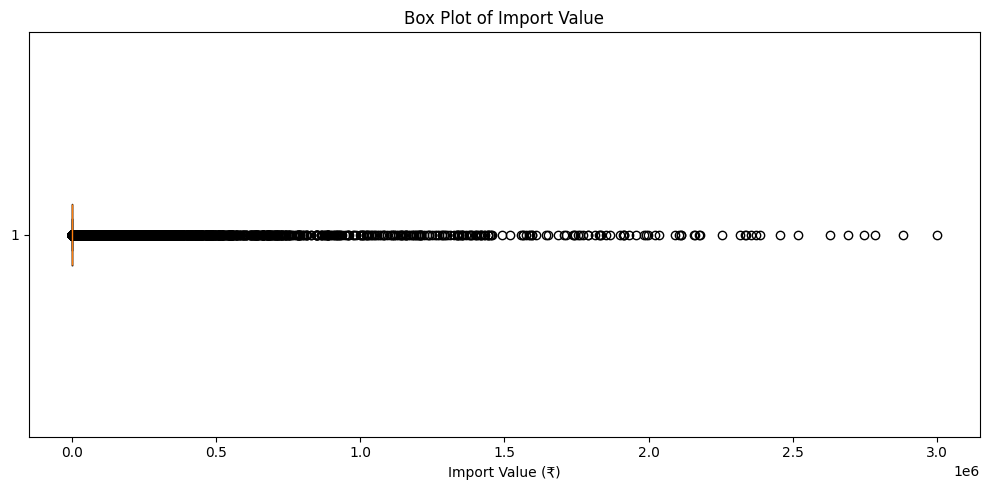

In [ ]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df['value_rs'].dropna(),
    vert=False
)

plt.title('Box Plot of Import Value')
plt.xlabel('Import Value (₹)')

plt.tight_layout()
plt.show()

**Interpretation**: The box plot shows that most import values are concentrated within a relatively low range, while numerous high-value observations extend far beyond the main distribution. This is consistent with the high standard deviation, positive skewness, and kurtosis observed in the statistical analysis, indicating substantial variation and extreme import-value observations.

**5.3 Univariate Analysis — Import Value Distribution**

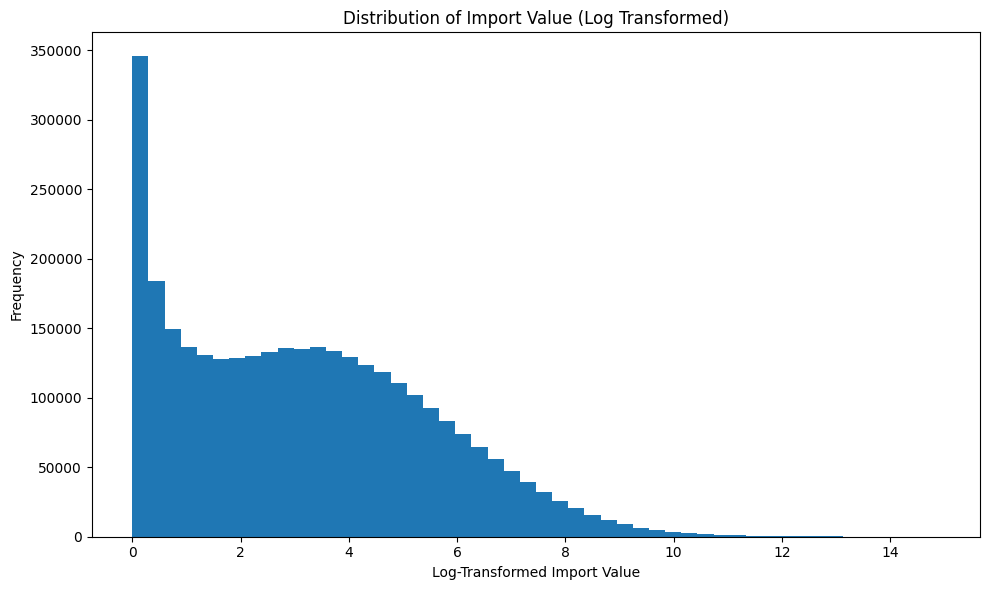

In [ ]:
plt.figure(figsize=(10, 6))

log_import_value = np.log1p(df['value_rs'].dropna())

plt.hist(
    log_import_value,
    bins=50
)

plt.title('Distribution of Import Value (Log Transformed)')
plt.xlabel('Log-Transformed Import Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation**: The distribution shows that most import records have relatively low import values, while a smaller number of records have substantially higher values. The long right tail indicates a highly right-skewed distribution, which is consistent with the high positive skewness observed in the statistical analysis.

**5.4 Bivariate Analysis**

**5.4.1 Total Import Value by Year**

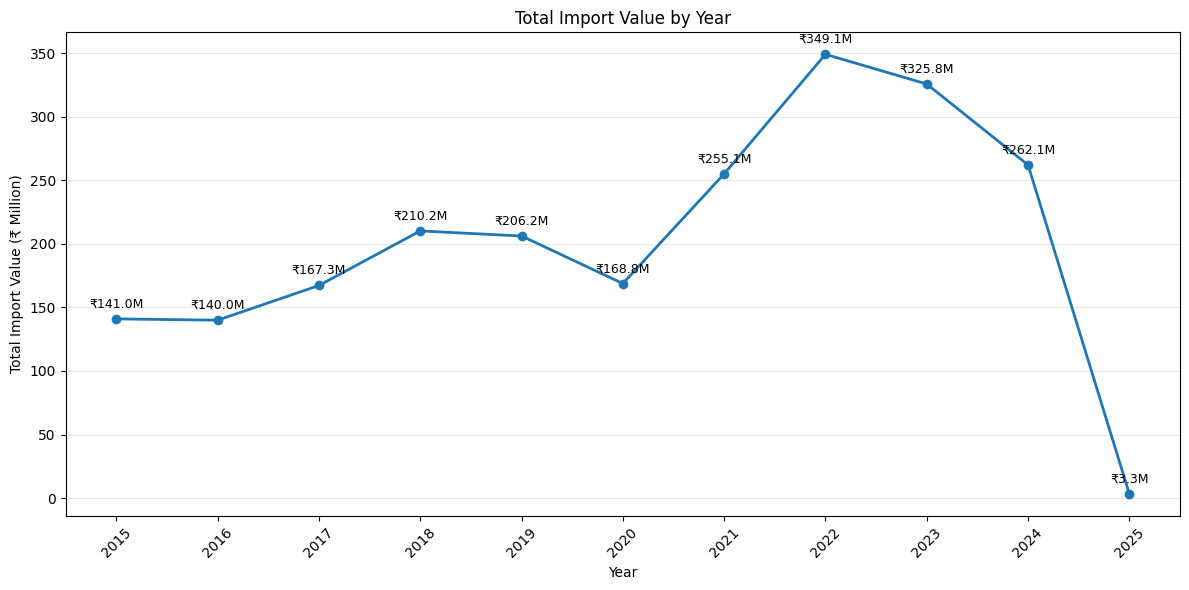

In [ ]:
plt.figure(figsize=(12, 6))

years = yearly_imports['year']
values_million = yearly_imports['total_value_rs'] / 1e6

plt.plot(
    years,
    values_million,
    marker='o',
    linewidth=2
)

# Add value labels
for x, y in zip(years, values_million):
    plt.annotate(
        f'₹{y:.1f}M',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9
    )

plt.title('Total Import Value by Year')
plt.xlabel('Year')
plt.ylabel('Total Import Value (₹ Million)')

plt.xticks(years, rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: India's total import value increased overall from approximately ₹141.0 million in 2015 to a peak of ₹349.1 million in 2022. Import value then declined in 2023 and 2024, reaching approximately ₹262.1 million in 2024. A sharp decline to approximately ₹3.3 million is observed in 2025. Since the number of trade records remains substantial in 2025, this unusual value should be interpreted cautiously and investigated further before drawing conclusions about the overall trend.

**5.4.2 Top 10 Import Countries by Total Import Value**

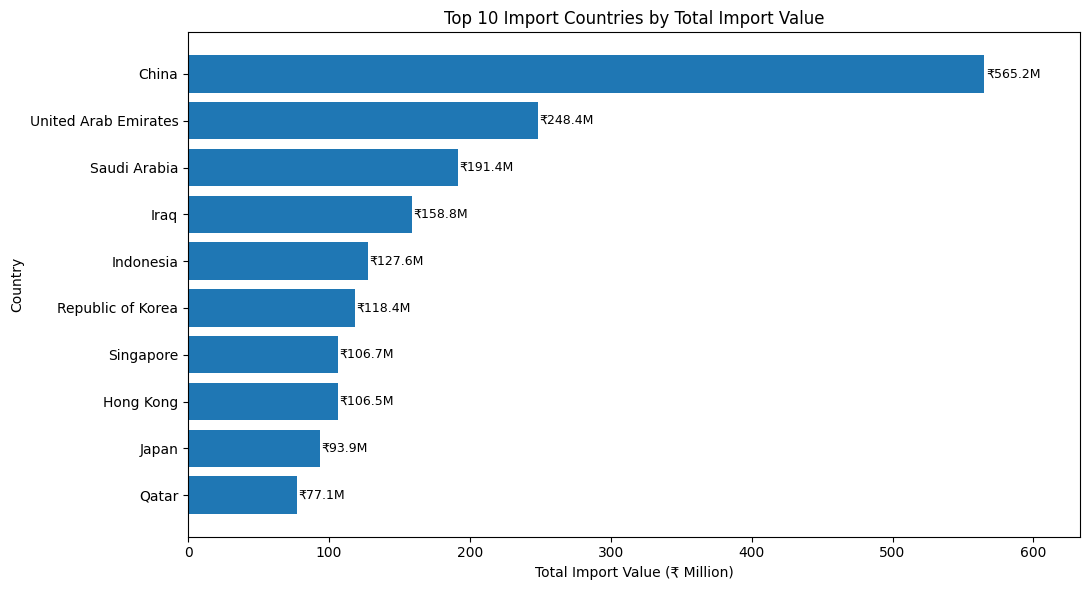

In [ ]:
country_imports = df.groupby('country_name').agg(
    total_value_rs=('value_rs', 'sum')
).reset_index()

top_10_countries = country_imports.sort_values(
    'total_value_rs',
    ascending=False
).head(10)

top_10_countries['value_million'] = (
    top_10_countries['total_value_rs'] / 1e6
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_10_countries['country_name'],
    top_10_countries['value_million']
)

plt.title('Top 10 Import Countries by Total Import Value')
plt.xlabel('Total Import Value (₹ Million)')
plt.ylabel('Country')

plt.gca().invert_yaxis()

for bar, value in zip(bars, top_10_countries['value_million']):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'₹{value:.1f}M',
        va='center',
        fontsize=9
    )

# Added extra space on right side of the label
max_value = top_10_countries['value_million'].max()
plt.xlim(0, max_value * 1.12)

plt.tight_layout()
plt.show()


**Interpretation**: China records the highest total import value among the major source countries, followed by the United Arab Emirates, Saudi Arabia and Iraq. The remaining countries contribute comparatively lower values. This indicates that import value is concentrated among a relatively small number of major trading partners.

**5.4.3 Top 10 Commodities by Total Import Value**

In [ ]:
commodity_imports = (
    df.groupby('commodity')['value_rs']
      .sum()
      .reset_index(name='total_value_rs')
)

top_10 = (
    commodity_imports
    .sort_values('total_value_rs', ascending=False)
    .head(10)
)

top_10['value_million'] = top_10['total_value_rs'] / 1e6

top_10

,commodity,total_value_rs,value_million
7781,Petroleum Oils And Oils Obtained From Bitumino...,2.905788e+08,290.578843
7780,Petroleum Crude,1.726088e+08,172.608839
5251,Other,1.147455e+08,114.745536
6602,Others,6.051067e+07,60.510672
5008,Non-Industrial Diamonds Unworked/Simply Sawn C...,5.360005e+07,53.600045
9228,Steam Coal,5.075981e+07,50.759812
4297,Liquified Natural Gas,4.857149e+07,48.571492
6019,Other Non-Monetary Unwrought Forms Of Gold,4.309373e+07,43.093730
4719,Monolithic Integrated Circuits - Digital,3.932595e+07,39.325955
2363,Crude Palm Oil And Its Fractns,3.882438e+07,38.824382


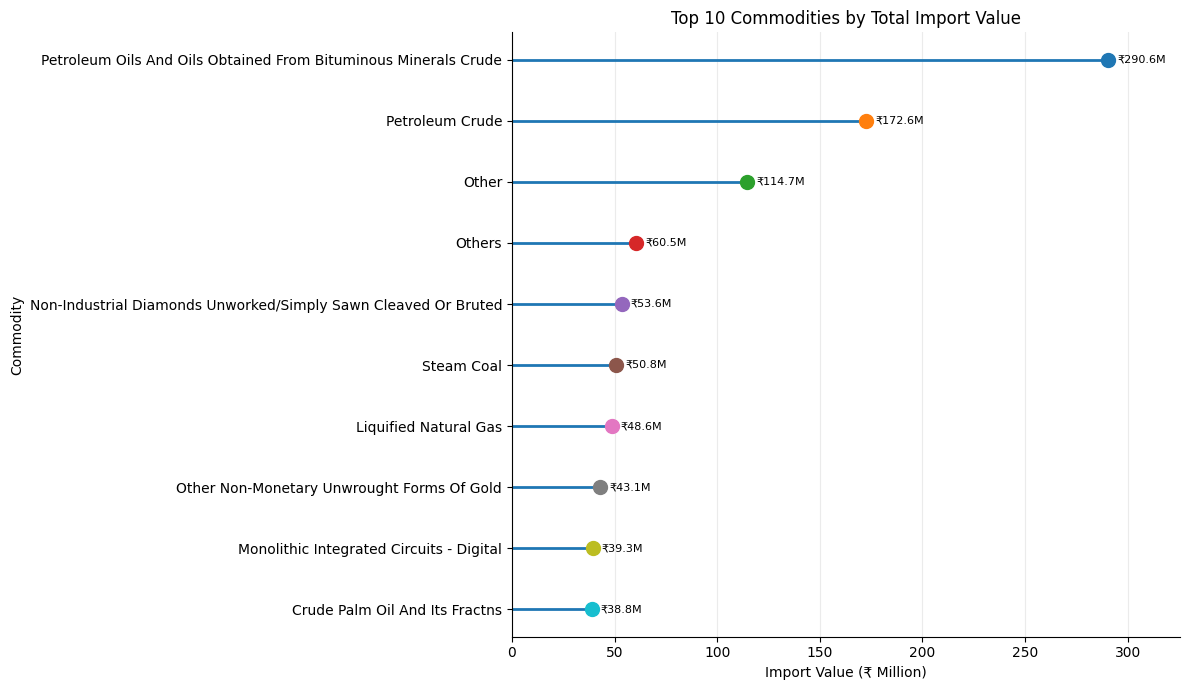

In [ ]:
top_10 = (
    commodity_imports
    .sort_values('total_value_rs', ascending=False)
    .head(10)
)

values = top_10['total_value_rs'] / 1e6
labels = top_10['commodity']

plt.figure(figsize=(12, 7))
ax = plt.gca()

y = range(len(labels))

for i, value in enumerate(values):
    ax.hlines(i, 0, value, linewidth=2)
    ax.scatter(value, i, s=100, zorder=3)
    ax.text(value + values.max() * 0.015, i, f'₹{value:.1f}M',
            va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()

ax.set_title('Top 10 Commodities by Total Import Value')
ax.set_xlabel('Import Value (₹ Million)')
ax.set_ylabel('Commodity')

ax.set_xlim(0, values.max() * 1.12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

**Interpretation**: Petroleum oils obtained from bituminous minerals record the highest total import value at approximately ₹290.6 million, followed by petroleum crude at approximately ₹172.6 million. Other major contributors include the source categories “Other” and “Others”, along with diamonds, steam coal, liquefied natural gas, gold, integrated circuits and crude palm oil. Overall, the results show that import value is strongly concentrated in a small number of high-value commodities, particularly petroleum and energy-related products.

**5.4.4 Unit-wise Import Value**

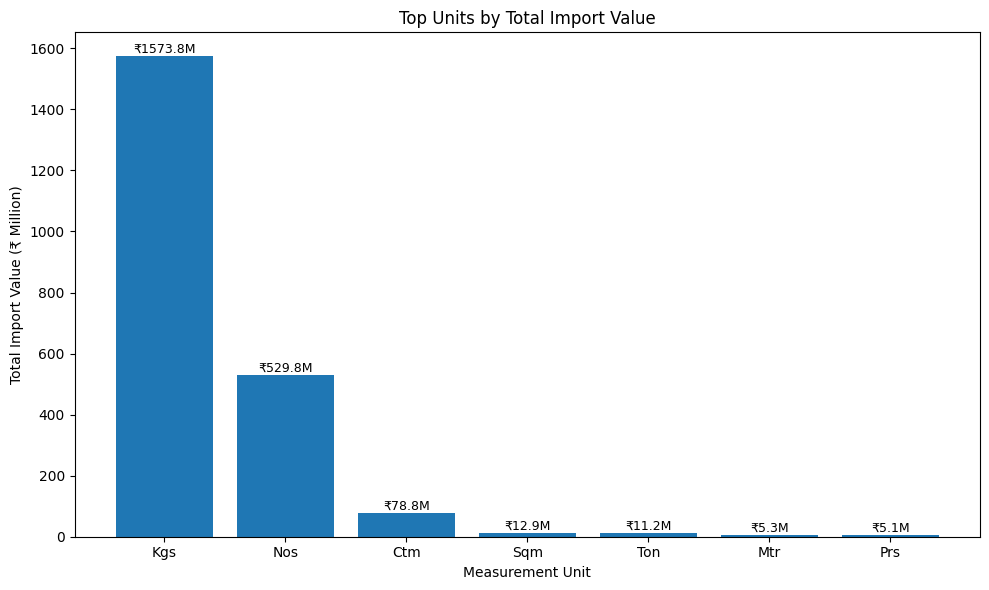

In [ ]:
unit_imports = df.groupby('unit').agg(
    total_value_rs=('value_rs', 'sum'),
    trade_records=('id', 'count')
).reset_index()

top_units = unit_imports.sort_values(
    'total_value_rs',
    ascending=False
).head(7)

top_units['value_million'] = (
    top_units['total_value_rs'] / 1e6
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_units['unit'],
    top_units['value_million']
)

plt.title('Top Units by Total Import Value')
plt.xlabel('Measurement Unit')
plt.ylabel('Total Import Value (₹ Million)')

for bar, value in zip(bars, top_units['value_million']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'₹{value:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: Import value is strongly concentrated in a few measurement-unit categories. Kgs accounts for the highest total import value, followed by Nos, while the remaining units contribute substantially lower values. This indicates that most recorded import value is associated with a limited number of measurement categories.

**5.4.5 Import Value by Trade Subregion**

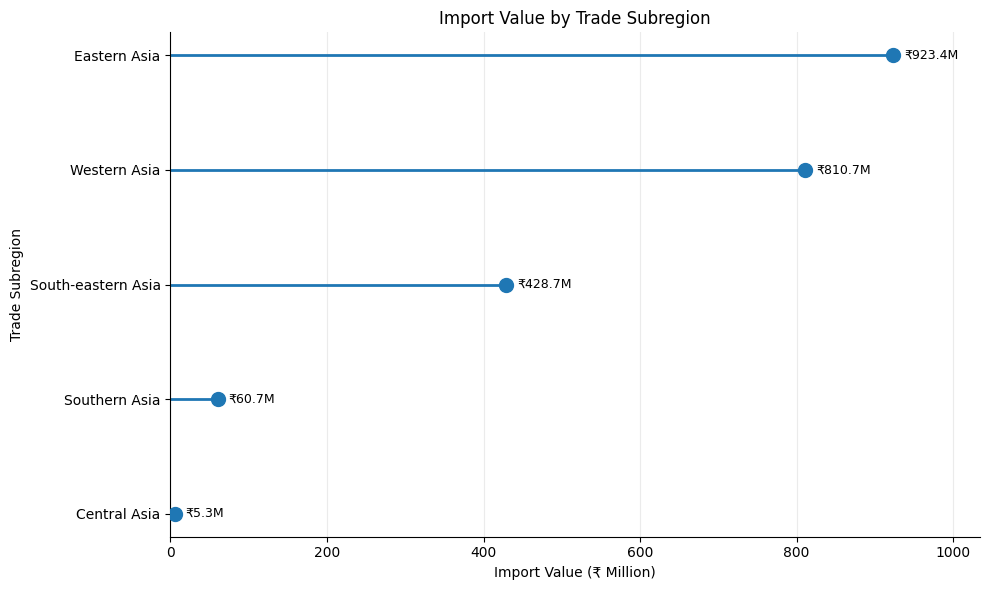

In [ ]:
subregion_imports = (
    df.groupby('subregion_name')['value_rs']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

subregion_imports['value_million'] = subregion_imports['value_rs'] / 1e6

plt.figure(figsize=(10, 6))
ax = plt.gca()

y = range(len(subregion_imports))
values = subregion_imports['value_million']

for i, value in enumerate(values):
    ax.hlines(i, 0, value, linewidth=2)

ax.scatter(values, y, s=100, zorder=3)

for i, value in enumerate(values):
    ax.text(value + values.max() * 0.015, i, f'₹{value:.1f}M',
            va='center', fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(subregion_imports['subregion_name'])
ax.invert_yaxis()

ax.set_title('Import Value by Trade Subregion')
ax.set_xlabel('Import Value (₹ Million)')
ax.set_ylabel('Trade Subregion')

ax.set_xlim(0, values.max() * 1.12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig('chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: The chart shows that import value varies across India’s Asian trade subregions, with some subregions contributing substantially more to total import value than others. This indicates that India’s import activity is geographically concentrated rather than evenly distributed across Asian subregions. The comparison helps identify the key subregions that contribute most to India’s import trade during 2015–2025.

**5.5 Multivariate Analysis**

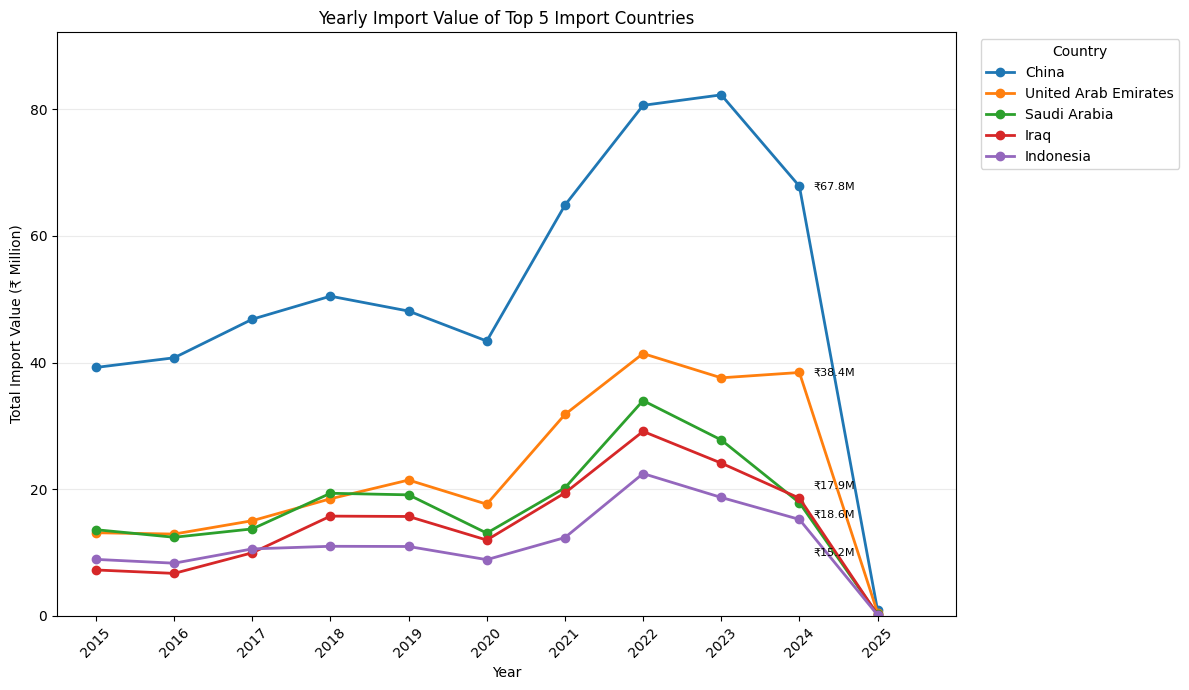

In [ ]:
# Top 5 import country names
top_5_country_names = (
    top_10_countries
    .head(5)['country_name']
    .tolist()
)

# Filter data for top 5 countries and calculate yearly imports
country_year_imports = df[
    df['country_name'].isin(top_5_country_names)
].groupby(
    ['year', 'country_name']
).agg(
    total_value_rs=('value_rs', 'sum')
).reset_index()

# Convert values to millions
country_year_imports['value_million'] = (
    country_year_imports['total_value_rs'] / 1e6
)

# Create figure
plt.figure(figsize=(12, 7))

ax = plt.gca()

# Different vertical positions for 2024 value labels
label_offsets = {
    top_5_country_names[0]: 0,    # China
    top_5_country_names[1]: 0,    # United Arab Emirates
    top_5_country_names[2]: 12,   # Saudi Arabia
    top_5_country_names[3]: -12,  # Iraq
    top_5_country_names[4]: -24   # Indonesia
}

# Plot each country
for country in top_5_country_names:

    country_data = country_year_imports[
        country_year_imports['country_name'] == country
    ]

    # Plot line
    ax.plot(
        country_data['year'],
        country_data['value_million'],
        marker='o',
        linewidth=2,
        label=country
    )

    # Only 2024 data for value labels
    label_data = country_data[
        country_data['year'] == 2024
    ]

    # Add 2024 value label
    if not label_data.empty:

        x = label_data['year'].iloc[0]
        y = label_data['value_million'].iloc[0]

        ax.annotate(
            f'₹{y:.1f}M',
            (x, y),
            xytext=(10, label_offsets[country]),
            textcoords='offset points',
            fontsize=8,
            va='center'
        )

# Chart title and labels
ax.set_title('Yearly Import Value of Top 5 Import Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Total Import Value (₹ Million)')

# X-axis formatting
ax.set_xticks(range(2015, 2026))
ax.set_xticklabels(range(2015, 2026), rotation=45)

# Extra space on the right for value labels
ax.set_xlim(2014.5, 2026)

# Automatically add space above highest value
max_value = country_year_imports['value_million'].max()
ax.set_ylim(0, max_value * 1.12)

# Legend
ax.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Add horizontal grid
ax.grid(axis='y', alpha=0.25)

# Adjust layout and display
plt.tight_layout()
plt.savefig('chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: China records the highest import value among the five major source countries across most of the study period. Its import value increased from approximately ₹39.2 million in 2015 to a peak of approximately ₹82.3 million in 2023 before declining to about ₹67.8 million in 2024. The United Arab Emirates also shows substantial growth, reaching approximately ₹38.4 million in 2024. Saudi Arabia, Iraq and Indonesia contribute lower values compared with China and the UAE. All five countries show unusually low values in 2025, consistent with the overall 2025 pattern in the dataset, so that year's values should be interpreted cautiously.

## **6. Documentation, Insights & Presentation**

### **6.1 Summary of Findings**
* This project analyzed India's import trade with Asian countries from 2015 to
2025 using Python. The analysis covered data exploration, data cleaning, transformation, feature engineering, descriptive statistics and data visualization.

* The analysis shows that India's import value varies substantially across countries, commodities and years. Import activity is concentrated among a relatively small number of major trading partners and high-value commodities.

* China emerged as the leading import source among the major countries analyzed. Petroleum-related commodities were among the largest contributors to total import value. Import values also showed strong positive skewness, indicating that a relatively small number of high-value trade records have a significant influence on the overall distribution.

* The yearly analysis showed an overall increase in import value from 2015 to a peak in 2022, followed by a decline in 2023 and 2024. An unusually low import value was observed for 2025 despite a substantial number of trade records, so this pattern should be investigated further before drawing conclusions about the 2025 trend.

### **6.2 Key Insights**

**1. Import value increased significantly over the study period**

Total import value increased from approximately ₹141.0 million in 2015 to approximately ₹349.1 million in 2022, which was the highest observed annual value in the analysis.

**2. China was the leading major import source**

China recorded the highest total import value among the major source countries, indicating its important contribution to India's import activity within the analyzed dataset.

**3. Petroleum-related commodities contributed heavily to import value**

Petroleum oils obtained from bituminous minerals recorded approximately ₹290.6 million, followed by petroleum crude at approximately ₹172.6 million. This indicates strong concentration of import value in energy-related commodities.

**4. Import values are highly uneven**

The mean import value was approximately ₹699.01, while the median was only ₹18.42. The large difference between these values, together with a skewness of approximately 90.41, indicates a strongly right-skewed distribution influenced by high-value observations.

**5. The dataset contains substantial variation and extreme observations**

The standard deviation of import value was approximately ₹14,421.60, considerably larger than the mean. The high kurtosis also indicates the presence of extreme observations in the import-value distribution.

### **6.3 Types of Analysis Performed**

####**Descriptive Analysis**

Descriptive analysis was performed to understand the structure and characteristics of the import dataset.

**The analysis included:**

* Dataset shape and structure

* Missing-value analysis

* Duplicate checks

* Unique-value analysis

* Mean, median and mode

* Variance and standard deviation

* Skewness and kurtosis

* Import trends by year

* Country-wise import value

* Commodity-wise import value

* Unit-wise import value

The results provided an overall understanding of India's import activity during the study period.

####**Diagnostic Analysis**

Diagnostic analysis was used to investigate why certain patterns appeared in the data.

**The analysis examined:**

* Differences between mean and median import values

* Highly skewed import-value distributions

* Extreme observations using the box plot

* Major countries contributing to import value

* Major commodities contributing to import value

* Changes in import value across years

* Unusual patterns in 2025

* Measurement-unit differences

The analysis indicates that the large variation in import value is mainly associated with the presence of relatively few high-value trade records.

####**Predictive Analysis**

Predictive modeling was not performed in this project.

* The project was designed primarily for descriptive and diagnostic analysis of historical import trade data. No forecasting or machine-learning model was developed.

Predictive modeling could be added as a future enhancement to forecast import values by year, country or commodity.

####**Prescriptive Analysis**

Based on the findings, the following decision-support recommendations can be considered:

* Monitor major import-source countries such as China and the United Arab Emirates closely.

* Track high-value commodities, particularly petroleum and other major energy-related products.

* Investigate large fluctuations in yearly import values.

* Examine unusual observations and extreme import-value records before making business or policy decisions.

* Validate the unusually low 2025 import value before using it for long-term trend conclusions.

* Use country- and commodity-level analysis to support more focused trade monitoring.

###**6.4 Decision Support**

The analysis can support decision-making by helping stakeholders:

* Identify major trading partners and monitor dependence on key source countries.

* Prioritize high-value commodities for detailed trade monitoring.

* Track yearly changes in import activity and investigate significant fluctuations.

* Investigate unusual values and extreme observations before drawing conclusions.

* Use more detailed country–commodity analysis for future trade planning and risk assessment.

### **6.5 Future Enhancement**

The project can be extended in the following ways:

* Use a larger or more recent dataset for deeper insights.

* Automate parts of the analysis using Python scripts or interactive dashboards.

* Develop predictive models for forecasting future import values.

* Perform country-level and commodity-level forecasting.

* Develop anomaly-detection techniques for unusual trade records.

* Extend the analysis to HS-code-level trade patterns.

* Build an interactive Power BI dashboard for country, commodity and yearly analysis.

* Analyze country–commodity relationships in greater detail.

### **6.6 Conclusion**

* This project demonstrates how Python-based data analytics can be used to transform a large-scale import trade dataset into meaningful insights.

* The analysis identified major import-source countries, high-value commodities, yearly import trends and significant variation in import values. Statistical analysis showed that import values are highly right-skewed, with extreme observations having a strong influence on the distribution.

* Overall, the project provides a structured view of India's import activity with Asian countries and demonstrates the use of EDA, data cleaning, transformation, feature engineering, statistical analysis and visualization for data-driven decision support.